## High-Resolution Wildfire Fuel Mapping in Alaska using Multimodal Imagery and tabular-based Fondation model

### 1 Introduction
### 1.1 Research Significance
Wildfires are increasing in frequency and intensity due to climate and land-use changes, posing major threats to ecosystems and communities. Within this context, Alaska represents a critical but under-researched frontier. Interior Alaska encompasses approximately 78 million hectares of boreal forest, which is highly vulnerable due to the presence of flammable black spruce and feather moss covering the ground surface. In 2022, Alaska accounted for about 40% of all U.S. burned acreage (over 3.1 million acreages). Despite this urgency, the volume of wildfire research focused on Alaska remains less than one-third comparing with that focused on the western United States, leaving a significant gap in sub-arctic wildfire related research. 

Among all research, the lack of high resolution spatial-temporal wildfire fuel maps is a significant issue.
Throughout the United States, the Landscape Fire and Resource Management Planning Tools (LANDFIRE) program provides the most commonly adopted fuel products, including the Anderson 13 and Scott & Burgan 40 standard surface fuel maps. Other widely applied fuel maps include: the Canadian Forest Fire Danger Rating System (CFFDRS), used in regions such as Alaska where temperatures are relatively low and prolonged droughts are infrequent. The above mentioned existing fuel maps rely on coarse 30-meter Landsat data, which limiting their utility for capturing fine-scale spatial variation and Wildland-Urban Interface (WUI) dynamics. What's more, these maps and their development rulesets do not transfer well to higher-resolution imagery. 

### 1.2 Objectives and Contributions 
To address these limitations, **this study proposes a foundation model-based pipeline for 10-meter resolution wildfire fuel mapping across Interior Alaska.** Our pipeline begins by synthesizing summer composites (June–August) of Sentinel-2 optical imagery, Sentinel-1 SAR data, PALSAR SAR data, and Digital Elevation Models (DEMs). These normal multi-modal remote sensing datasets are then integrated with the AlphaEarth (AEF) geoscientific foundation model to extract deep, high-dimensional spatiotemporal features. Subsequently, a pseudo-labeling strategy is implemented by randomly sampling training sample points on 30-meter CFFDRS fuel map to establish 'multimodal features - fuel category' training pairs. Finally, by leveraging the transformer-based tabular foundation model(TabPFN), the pipeline achieves an end-to-end transition from coarse, noisy 30-meter resolution existing fuel maps to high-fidelity, 10-meter resolution wildfire fuel maps across Alaska. 

**Our proposed pipeline presents the following contributions**：

-**Multimodal Training Dataset for Wildfire Fuel Mapping**: This work established a multimodal training dataset for Alaska wildfire fuel mapping by employing a pseudo-labeling strategy that aligns 30m existing fuel products with 10m multi-modal satellite observations.

-**Foundation Model Efficacy Exploration**: This work systematically evaluated two Foundation Models (AlphaEarth as input data, TabPFN), and their abilities to handle traditional mapping tasks.

-**10-meter Resolution Resulting CFFDRS Fuel Map**: This work generated a 10-meter wildfire fuel map for Alaska based on the CFFDRS classification category, providing spatial detail for fire behavior modeling and risk assessment.

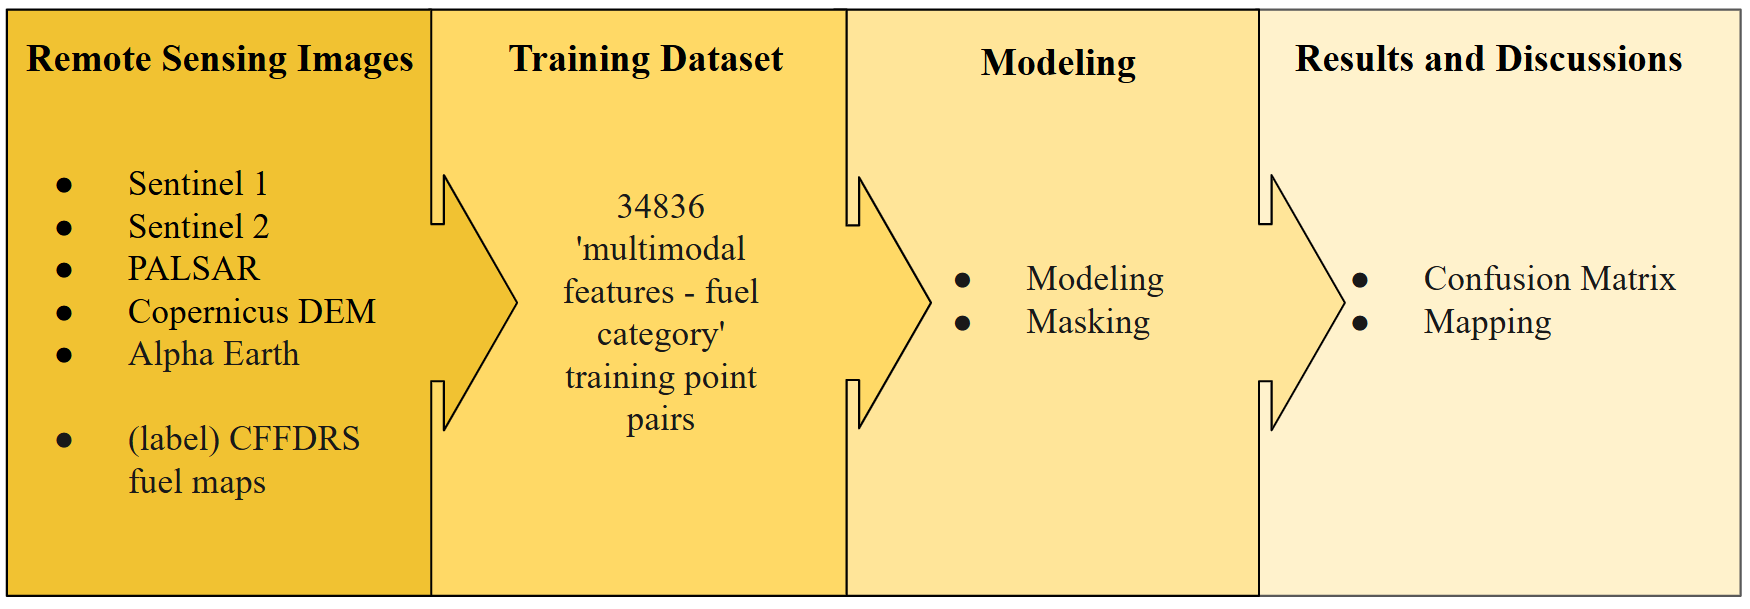

In [5]:
# Function to display the "Propsoed workflow for wildfire fuel mapping"
from IPython.display import Image, display
display(Image("Propsoed workflow for wildfire fuel mapping.png", width=800))

## 2 Overview 
### Above figure shows the proposed workflow for wildfire fuel mapping, introductions for all steps in this workflow are as follows:
 - **Step0**: Setup Necessary Dependencies: Install and import the specialized libraries and packages needed for the project.

 - **Step1**: Data Introduction and Load Training Dataset: The first part of this step introduces all remote sensing data sources and load multimodal imagery (Sentinel-1/2, PALSAR, DEM, AlphaEarth) for final mapping; The second part of this step shows some examples of the training sample point pairs, and then load them for modeling

 - **Step2**: Build and Train the Model: Configure and train the TabPFN classifier. Includes an explanation of what a tabular foundation model is and why it is useful for small-sample learning and handling noisy labels.

 - **Step3**: Results and Discussions: valuate the 10m fuel mapping performance. Includes analyses of classification accuracy (Confusion Matrix), and detailed resulting maps.
 

### Step0: Setup Necessary Dependencies
The purpose of this step is to create a clean Python environment for running TabPFN-based classification experiments, including install tabpfn/ tabpfn-extensions/ all necessary support packages, then download pretrained model from the Huggingface Hub. To successfully install tabpfn/ tabpfn-extension, we need to ensure that python >= 3.9. So in order to avoid dependency conflicts with the base environment, a new conda environment named tabpfn_clean was created using Python 3.11.

```bash
# Create conda environment 
conda create -n tabpfn_clean python=3.11 -y
conda activate tabpfn_clean

# Install dependencies
# After activating the new environment, the package manager tools were upgraded first to ensure compatibility during installation. Then the required libraries for the TabPFN workflow were installed:
pip install --upgrade pip setuptools wheel
pip install tabpfn
pip install tabpfn-extensions
```
TabPFN v2.5 requires downloading model weights from the Huggingface Hub. Since the repository is gated, access must be manually approved before the model can be downloaded. 
First, we install "huggingface_hub[cli]" and run command-line authentication to gain model access from Huggingface. When the script attempt to download the model from Huggingface, access to the gated repository have to be enabled manually in the browser. 
Second, the user open the model page, review the terms, and accept access. After approval, we click the profile and open 'access tokens' page to create a read only permission token.
The token value was then copyed and imported into the server environment through the Huggingface CLI. After login in and pasted the token value into the terminal to authenticate the current environment, you are able to use the TabPFN. 
 
```bash
# install huggingface hubcli
pip install -U "huggingface_hub[cli]"
hf auth login --force
```

### Step1: Data Introduction and Load Training Dataset
This part briefly introduces the multimodal image we used here in the project and describes the procedure for building the point-based training dataset. It contains two parts. The first part introduces the remote sensing data sources used for fuel mapping. The second part explains how random sample points were generated from the study area and how point-based training samples were constructed for subsequent modeling.

**Remote Sensing Data Sources**
 - PALSAR: 25m yearly mosaic, HH and HV polarizations
 - Sentinel-1:10m, VV and VH polarizations
 - Elevation: 30m, Copernicus DEM GLO-30,select elevation then calculate slope and aspect 
 - Sentienl-2: 10m, Take median from June-August, 'Blue','Green','NIR','Red','SWIR1','SWIR2',
 - AlphaEarth: 10m,  AEF is google’s newly published 64 dimension embeddings, it provides an information-dense global geospatial representation of the Earth’s surface. Essentially, the AEF transforms  - complex Earth observation data into a more structured and dense latent representations.
 - (label) CFFDRS: 30m,  categorize surface fuels within alaska into 23 different classes

Together, these datasets provide a multimodal description of the landscape. Optical data capture spectral properties, SAR data provide structural-related information, topographic variables represent terrain, and AlphaEarth embeddings contribute high-level feature representations. This combination forms the basis for point-based fuel classification.

**Dataset for training**

After preparing the multimodal imagery, we constructed a point-based training dataset for classification. The goal of this step was to transform raster-based multimodal data into tabular point samples that can be directly used by machine learning models.Random sample points were generated within the study area (interior Alaska). The sampling process was designed to ensure that each point falls on a location with available remote sensing observations and a corresponding CFFDRS label.

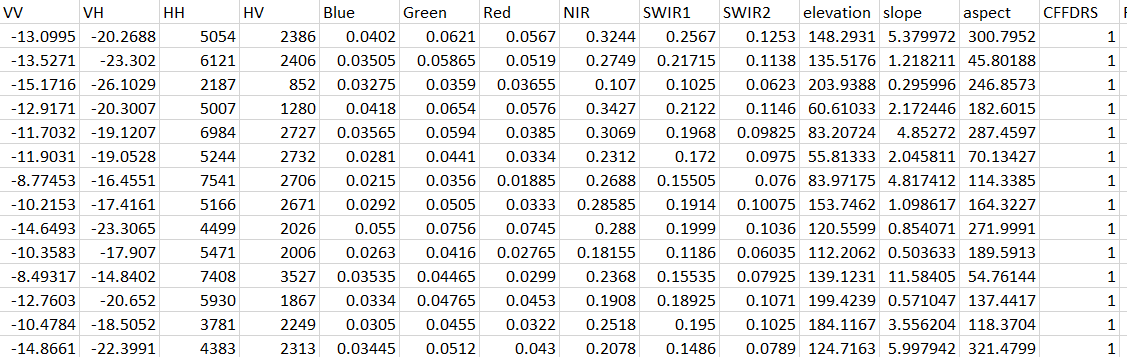

In [7]:
from IPython.display import Image, display
display(Image("Examples of the training sample point pairs.png", width=800))

### Step2: Build and Train the Model
This part shows the complete code we used to train and evaluation models.

In [ ]:
## 1. Import all necessary libraries
import os
import joblib
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold

from tabpfn import TabPFNClassifier
from tabpfn_extensions.many_class import ManyClassClassifier
from lightgbm import LGBMClassifier

try:
    import torch
except ImportError:
    torch = None


# 2. Parameters and settings
FILE_PATH = r"cffdrs_alaska_training_samples(example).csv"
MODEL_SAVE_PATH = r"tabpfn_direct_bundle.pkl"
N_SPLITS = 5   # K-fold and random seed settings.
RANDOM_STATE = 42
IGNORE_PRETRAINING_LIMITS = False # Set this to True when dataset is larger than TabPFN's default pretraining limits.  TabPFN-2.5 supports up to about 50,000 rows and 2,000 features  
TABPFN_N_ESTIMATORS = 8
DEVICE = "cuda" if (torch is not None and torch.cuda.is_available()) else "cpu"

# Choose the feature subset you want to use and record the original label values.
ORIGINAL_BANDS = [1, 2, 3, 5, 7, 13, 23, 31, 32, 33, 40, 50, 60, 101, 102, 425, 605, 620, 625, 680] # original band indices in the CSV file 
MULTIMODAL_COLUMNS = ['Blue','Green','HH','HV','NIR','Red','SWIR1','SWIR2','VH','VV','aspect','elevation','slope']
AEF_COLUMNS =       ['A00','A01','A02','A03','A04','A05','A06','A07','A08','A09','A10','A11','A12','A13','A14','A15',
                        'A16','A17','A18','A19','A20','A21','A22','A23','A24','A25','A26','A27','A28','A29','A30',
                       'A31','A32','A33','A34','A35','A36','A37','A38','A39','A40','A41','A42','A43','A44','A45',
                       'A46','A47','A48','A49','A50','A51','A52','A53','A54','A55','A56','A57','A58','A59','A60','A61','A62','A63']
DATAMODE_COLUMNS = AEF_COLUMNS
LABEL_COLUMN = "CFFDRS"
 

# 3. Functions for model building, evaluation, and saving
# This function builds the TabPFN estimator, using ManyClassClassifier if there are more than 10 classes.
def build_tabpfn_estimator(n_classes: int, device: str = DEVICE, random_state: int = 42):
    base_estimator = TabPFNClassifier(device=device)

    if n_classes > 10:
        print("Info: More than 10 classes detected, so ManyClassClassifier will be used.")
        model = ManyClassClassifier(
            estimator=base_estimator,
            alphabet_size=10,
            n_estimators_redundancy=4,
            random_state=random_state,
        )
    else:
        model = base_estimator

    return model

# This function builds a LightGBM model with specified hyperparameters. Used for comparison in the ablation study.
def lightgbm_model(X_train, y_train_encoded, class_weights = None, seed=42):
    model = LGBMClassifier(
    objective='multiclass',
    num_class=len(ORIGINAL_BANDS),
    n_estimators=100,
    learning_rate=0.05,
    max_depth=-1,         # 不限制深度，用 num_leaves 控制复杂度
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    )
    model.fit(X_train, y_train_encoded)
    return model

# This function evaluates the predictions for a fold and prints the accuracy and macro F1 score.
def evaluate_fold(y_true_enc, y_pred_enc, fold=None, prefix=""):
    """Compute fold-level metrics."""
    acc = accuracy_score(y_true_enc, y_pred_enc)
    f1m = f1_score(y_true_enc, y_pred_enc, average="macro")
    msg = f"{prefix}Fold {fold}: acc={acc:.4f}, macroF1={f1m:.4f}"
    print(msg)
    return {"acc": acc, "macro_f1": f1m}

# This function saves the trained model and label encoder as a bundle for later inference.
def save_models(model, encoder):
    """Save the fitted model bundle for later inference."""
    bundle = {
        "model": model,
        "label_encoder": encoder,
        "scaler": None,
        "original_band_indices": ORIGINAL_BANDS,
        "saved_band_indices": list(range(len(DATAMODE_COLUMNS))),
        "feature_columns": DATAMODE_COLUMNS,
    }
    joblib.dump(bundle, MODEL_SAVE_PATH)
    print(f"Model bundle saved to: {MODEL_SAVE_PATH}")

# Main function to run k-fold cross validation with direct TabPFN usage.
def main_kfold_tabpfn_direct():
    """Run k-fold cross validation with direct TabPFN usage."""
    if not os.path.exists(FILE_PATH):
        raise FileNotFoundError(f"File not found: {FILE_PATH}")

    df = pd.read_csv(FILE_PATH)

    feature_cols = DATAMODE_COLUMNS if DATAMODE_COLUMNS is not None else [c for c in df.columns if c != LABEL_COLUMN]

    X_all = df[feature_cols].values.astype(np.float32)
    y_all = df[LABEL_COLUMN].values

    encoder = LabelEncoder()
    y_all_encoded = encoder.fit_transform(y_all)

    n_classes = len(encoder.classes_)
    n_samples = X_all.shape[0]

    print("=" * 60)
    print("TabPFN direct usage")
    print(f"Device: {DEVICE}")
    print(f"Samples: {n_samples}")
    print(f"Features: {X_all.shape[1]}")
    print(f"Classes: {n_classes}")
    print(f"Class counts: {dict(Counter(y_all))}")
    print("=" * 60)

    if n_classes > 10:
        print("Info: More than 10 classes detected, so ManyClassClassifier will be used.")

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    oof_pred = np.full(n_samples, -1, dtype=np.int32)
    oof_proba = np.zeros((n_samples, n_classes), dtype=np.float32)
    fold_metrics = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_all_encoded), start=1):
        X_tr, X_va = X_all[tr_idx], X_all[va_idx]
        y_tr, y_va = y_all_encoded[tr_idx], y_all_encoded[va_idx]

        print(f"\n[Fold {fold}/{N_SPLITS}] Training TabPFN...")
        model = build_tabpfn_estimator(n_classes=n_classes, device=DEVICE)
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_va)
        pred = np.argmax(proba, axis=1)

        oof_proba[va_idx] = proba
        oof_pred[va_idx] = pred

        metrics = evaluate_fold(y_va, pred, fold=fold, prefix="[TabPFN-Direct] ")
        fold_metrics.append(metrics)

    accs = [m["acc"] for m in fold_metrics]
    f1s = [m["macro_f1"] for m in fold_metrics]

    print("\n================ K-Fold Summary ================")
    print(f"TabPFN mean acc     = {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"TabPFN mean macroF1 = {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print("Classification Report:")
    print(classification_report(y_all_encoded, oof_pred, zero_division=0))

    print("\nTraining final TabPFN model on all data...")
    final_model = build_tabpfn_estimator(n_classes=n_classes, device=DEVICE)
    final_model.fit(X_all, y_all_encoded)
    save_models(final_model, encoder)

    print("Done.")


if __name__ == "__main__":
    main_kfold_tabpfn_direct()


### Step3: Results and Discussions 
**Discussion towards the usage of AlphaEarth Foundations**

We try two kinds of feature combinations here：1. MULTIMODAL_COLUMNS only; 2. MULTIMODAL_COLUMNS + AEF_COLUMNS. And the per-class F1-score comparison are showed below:

MULTIMODAL_COLUMNS = ['Blue','Green','HH','HV','NIR','Red','SWIR1','SWIR2','VH','VV','aspect','elevation','slope']

AEF_COLUMNS        = ['A00','A01','A02','A03','A04','A05','A06','A07','A08','A09','A10','A11','A12','A13','A14','A15',
                        'A16','A17','A18','A19','A20','A21','A22','A23','A24','A25','A26','A27','A28','A29','A30',
                       'A31','A32','A33','A34','A35','A36','A37','A38','A39','A40','A41','A42','A43','A44','A45',
                       'A46','A47','A48','A49','A50','A51','A52','A53','A54','A55','A56','A57','A58','A59','A60','A61','A62','A63']

As can be concluded from the evalution metrics and result images: adding AEF leads to more stable large patches and makes broad classes easier to form spatially continuous regions. As a result, the classification map contains fewer isolated noisy pixels and appears visually smoother, although class boundaries may become less sharp. This pattern suggests that AEF provides additional semantic cues and contextual information, so the point-based classifier is no longer relying only on the local values at individual training points. Instead, it gains stronger regional consistency and better internal homogeneity within the same class, but this improvement comes with some loss of edge precision. According to the result F1-score table, all classes show a massive accury improvement, which further enhance the ability of AlphaEarth Foundations.
| Class | F1 (Without AEF) | F1 (With AEF) | ΔF1 |
|---|---:|---:|---:|
| 1  | 0.60 | 0.75 | +0.15 |
| 2  | 0.62 | 0.76 | +0.14 |
| 3  | 0.56 | 0.73 | +0.17 |
| 5  | 0.44 | 0.68 | +0.24 |
| 7  | 0.86 | 0.94 | +0.08 |
| 13  | 0.49 | 0.67 | +0.18 |
| 23 | 0.56 | 0.66 | +0.10 |
| 31  | 0.73 | 0.87 | +0.14 |
| 32  | 0.59 | 0.74 | +0.15 |
| 33  | 0.61 | 0.77 | +0.16 |
| 40 | 0.45 | 0.68 | +0.23 |
| 50 | 0.94 | 0.96 | +0.02 |
| 60 | 0.32 | 0.49 | +0.17 |
| 101 | 0.91 | 0.93 | +0.02 |
| 102 | 0.99 | 0.99 | +0.00 |
| 425 | 0.54 | 0.71 | +0.17 |
| 605 | 0.33 | 0.47 | +0.14 |
| 620 | 0.67 | 0.83 | +0.16 |
| 625 | 0.82 | 0.88 | +0.06 |
| 680 | 0.29 | 0.79 | +0.50 |

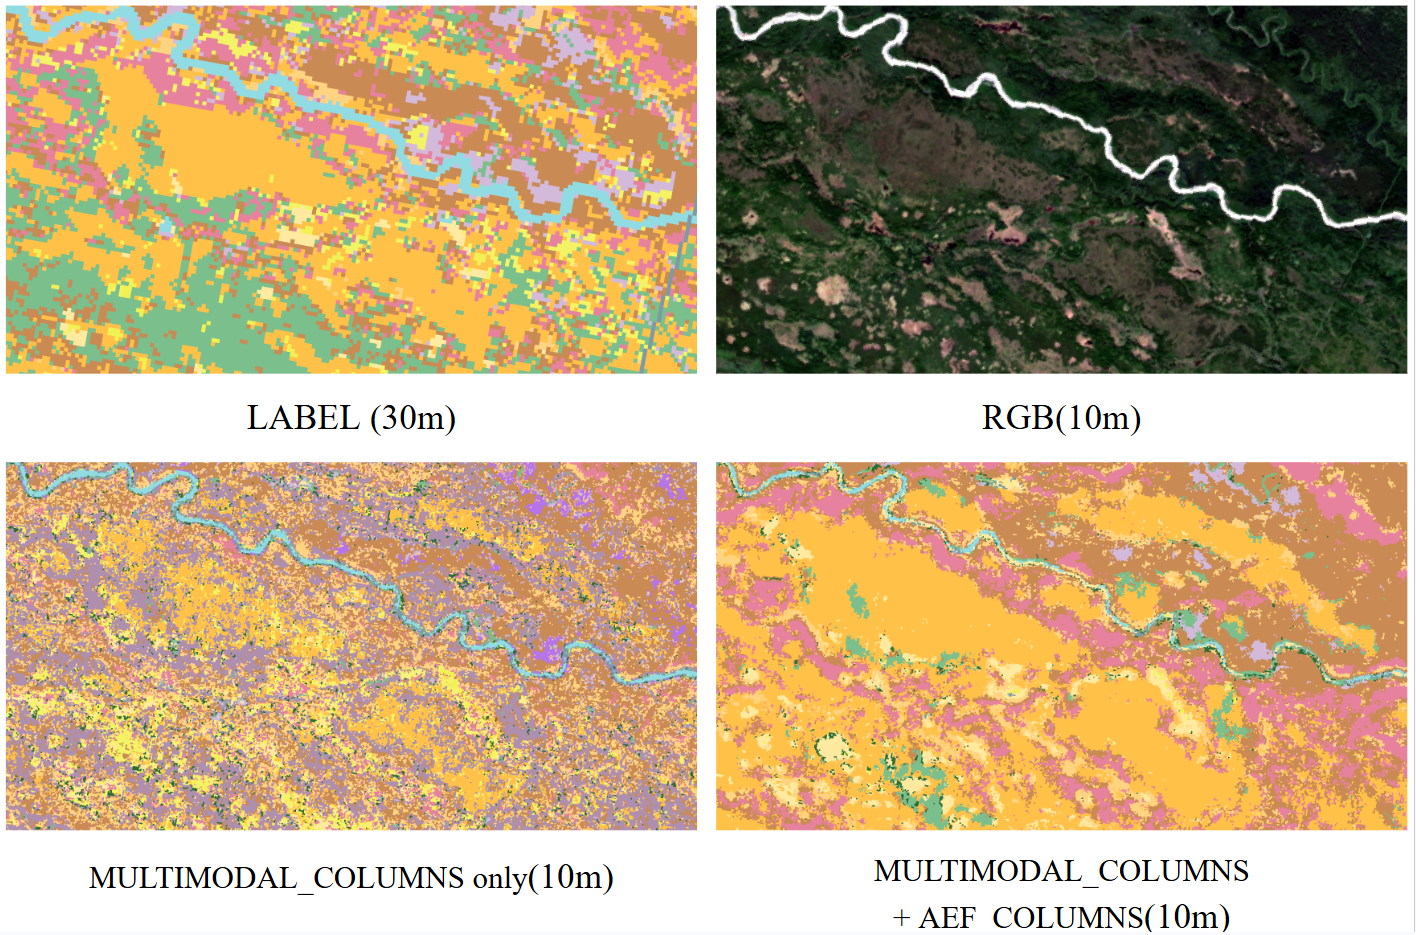

In [8]:
from IPython.display import Image, display
display(Image("The usage of AlphaEarth Foundations.png", width=800))

**Discussion towards the usage of TabPFN**

Compared with the trained LightGBM model, TabPFN achieved clearly better overall performance, improving mean accuracy from 0.6342 to 0.7208 and macro-F1 from 0.6099 to 0.6936. 
At the per-class level, TabPFN showed consistent gains across most categories, with especially notable improvements on difficult classes such as 60, 605, and 680. These results suggest that a pretrained tabular foundation model can not only match but also exceed the performance of a conventionally trained LightGBM classifier in this task. This supports the reliability of pretrained foundation models for multimodal fuel classification and indicates that their learned prior knowledge can transfer effectively to downstream geospatial tabular prediction problems, even without heavy task-specific model engineering.

| CFFDRS Class | F1 (LightGBM) | F1 (TabPFN) | ΔF1 |
|---|---:|---:|---:|
| 1   | 0.60 | 0.68 | +0.08 |
| 2   | 0.61 | 0.69 | +0.08 |
| 3   | 0.55 | 0.64 | +0.09 |
| 5   | 0.44 | 0.59 | +0.15 |
| 7   | 0.85 | 0.90 | +0.05 |
| 13  | 0.48 | 0.58 | +0.10 |
| 23  | 0.54 | 0.67 | +0.13 |
| 31  | 0.73 | 0.79 | +0.06 |
| 32  | 0.58 | 0.66 | +0.08 |
| 33  | 0.61 | 0.69 | +0.08 |
| 40  | 0.47 | 0.57 | +0.10 |
| 50  | 0.93 | 0.93 | +0.00 |
| 60  | 0.31 | 0.41 | +0.10 |
| 101 | 0.89 | 0.93 | +0.04 |
| 102 | 0.99 | 0.99 | +0.00 |
| 425 | 0.53 | 0.63 | +0.10 |
| 605 | 0.31 | 0.40 | +0.09 |
| 620 | 0.67 | 0.75 | +0.08 |
| 625 | 0.82 | 0.87 | +0.05 |
| 680 | 0.30 | 0.52 | +0.22 |

### Conclusions and Further steps

This comparison demonstrates that Alpha Earth foundation models can play a very useful role in classification tasks, particularly in table-based classification, where they are able to provide contextual information that is typically lacking in conventional methods of this kind.
What's more, our experiments also shows that the pretrained foundation model TabPFN is a reliable and competitive solution for tabular-based classification, achieving performance comparable to or better than the trained LightGBM baseline.

In the next stage, three directions will be prioritized:
 - First, the classification results should be further validated using field-observed FIA plot data to assess their agreement with real-world fuel conditions. 
 - Second, time-series imagery should be incorporated to better separate confused classes, especially those leafless/leaf classes and misclassification between broadleaf forests and coniferous forests. 
 - Third, the resulting fuel maps should be integrated into fire behavior models to evaluate their practical value in downstream applications.

For any questions related to this work, please feel free to contact the author:
Chenyan Lu, Arizona State University, chenya23@asu.edu

### References:  
Alipour, M., La Puma, I., Picotte, J., Shamsaei, K., Rowell, E., Watts, A., Kosovic, B., Ebrahimian, H., & Taciroglu, E. (2023). A Multimodal Data Fusion and Deep Learning Framework for Large-Scale Wildfire Surface Fuel Mapping. Fire, 6(2), Article 2. https://doi.org/10.3390/fire6020036

Hollmann, N., Müller, S., Purucker, L., Krishnakumar, A., Körfer, M., Hoo, S. B., Schirrmeister, R. T., & Hutter, F. (2025). Accurate predictions on small data with a tabular foundation model. Nature, 637(8045), 319–326. https://doi.org/10.1038/s41586-024-08328-6

Shaik, R. U., Alipour, M., Rowell, E., Balaji, B., Watts, A., & Taciroglu, E. (2025). FUELVISION: A multimodal data fusion and multimodel ensemble algorithm for wildfire fuels mapping. International Journal of Applied Earth Observation and Geoinformation, 138, 104436. https://doi.org/10.1016/j.jag.2025.104436

Brown, C. F., Kazmierski, M. R., Pasquarella, V. J., Rucklidge, W. J., Samsikova, M., Zhang, C., Shelhamer, E., Lahera, E., Wiles, O., Ilyushchenko, S., Gorelick, N., Zhang, L. L., Alj, S., Schechter, E., Askay, S., Guinan, O., Moore, R., Boukouvalas, A., & Kohli, P. (2025). AlphaEarth Foundations: An embedding field model for accurate and efficient global mapping from sparse label data (arXiv:2507.22291). arXiv. https://doi.org/10.48550/arXiv.2507.22291
